In [1]:
#source activate newEnv
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
library(tibble)
library(broom)
library("parallel")
library(tidyr)
library(stringr)
library(qvalue)

Warning message:
“package ‘qvalue’ was built under R version 4.4.2”


# Write State commands

In [2]:
trait_beds <- rev(list.files('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits/', full.names = TRUE)) #full.names makes sure you have the full file path

In [5]:
head(trait_beds)

[1] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed"
[2] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.EUR.MVP.2021.credset.bed"  
[3] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T2D_WIDE_Hg38.bed"       
[4] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T2D_Hg38.bed"            
[5] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T1D_Hg38.bed"            
[6] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T1D_EARLY_Hg38.bed"

In [6]:
out.dir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/'

In [7]:
Sys.time()
commands <- character()
homer.commands <- character()

# Run for DE sites
for(FILE in trait_beds[1]){
    cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed',
    results2 <- NULL #Create an empty dataframe to store results from loop
    message(FILE)
    
    for (cluster in 0:8) {
        background_name <- paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/all.peaks.bed')

        input_name <- paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/LiverUnionPeaks.r9n10.module',cluster,'.bed')
        commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                           out.dir,cluster,'__cre.module.results'))
        homer.commands <- c(homer.commands, paste0('findMotifsGenome.pl ',input_name,' hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.modules.',
                     cluster,'/ -size 200 -bg ',background_name,' -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer'))
    }
}

Sys.time()

length(commands)
head(commands)
tail(commands)

commands[str_detect(commands, 'nfs')]

length(homer.commands)
head(homer.commands)
tail(homer.commands)

homer.commands[str_detect(homer.commands, 'nfs')]

[1] "2025-04-28 14:57:50 PDT"

/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed



[1] "2025-04-28 14:57:50 PDT"

[1] 9

[1] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/LiverUnionPeaks.r9n10.module0.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/all.peaks.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/0__cre.module.results"
[2] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/LiverUnionPeaks.r9n10.module1.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/all.peaks.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/1__cre.module.results"
[3] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/LiverUnionPeaks.r9n10.module2.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/all.peaks.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/2__cre.module.results"
[4] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/LiverUnionPeaks.r9n10.module3.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/all.peaks.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/3__cre.module.results"
[5] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/LiverUnionPeaks.r9n10.module4.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/all.peaks.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/4__cre.module.results"
[6] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/LiverUnionPeaks.r9n10.module5.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/all.peaks.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/5__cre.module.results"

...

character(0)

[1] 9

[1] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/LiverUnionPeaks.r9n10.module0.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.modules.0/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/all.peaks.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"
[2] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/LiverUnionPeaks.r9n10.module1.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.modules.1/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/all.peaks.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"
[3] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/LiverUnionPeaks.r9n10.module2.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.modules.2/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/all.peaks.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"
[4] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/LiverUnionPeaks.r9n10.module3.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.modules.3/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/all.peaks.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"
[5] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/LiverUnionPeaks.r9n10.module4.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.modules.4/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/all.peaks.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"
[6] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/LiverUnionPeaks.r9n10.module5.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.modules.5/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/all.peaks.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"

[1] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/LiverUnionPeaks.r9n10.module3.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.modules.3/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/all.peaks.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"
[2] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/LiverUnionPeaks.r9n10.module4.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.modules.4/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/all.peaks.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"
[3] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/LiverUnionPeaks.r9n10.module5.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.modules.5/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/all.peaks.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"
[4] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/LiverUnionPeaks.r9n10.module6.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.modules.6/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/all.peaks.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"
[5] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/LiverUnionPeaks.r9n10.module7.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.modules.7/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/all.peaks.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"
[6] "findMotifsGenome.pl /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/LiverUnionPeaks.r9n10.module8.bed hg38 /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/outs/cre.modules.8/ -size 200 -bg /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/cre.modules/all.peaks.bed -mknown /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/12_HOMER/240722_WE_JASPAR_2022_monaLisa_Dump_noPseudo.homer"

character(0)

In [8]:
write.table(commands, '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/250428_commands_NAFLD_TRANS_ancestry.txt',col.names=F, row.names=F, quote=F, sep='\t')

In [9]:
write.table(homer.commands, '/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/250428_commands.txt',col.names=F, row.names=F, quote=F, sep='\t')

# Read FINRICH

In [11]:
out.df <- data.frame()

for (cluster in 0:8) {
    file.path <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/',cluster,'__cre.module.results')
    if (!file.exists(file.path)) {
        next
    }

    res <- unlist(strsplit(readLines(file.path)[1], ":|,|}"))
    if (!is.na(res[1])){
        results <- data.frame(matrix(ncol=0, nrow=1))
        results$module <- paste0('M',cluster)
        results$pval <- res[2]
        results$fold_enrich <- res[4]
        results$logOR <- res[6]
        results$conf_lower <- res[8]
        results$conf_upper  <- res[10]
    } else {
        message(file.path)
    }
    out.df <- rbind(out.df, results)
}

dim(out.df)
head(out.df)

[1] 9 6

,module,pval,fold_enrich,logOR,conf_lower,conf_upper
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,M0,0.62,0.8133892875063709,-0.23382410629355477,-1.235106118544416,1.2143437673137019
2,M1,0.964,0.19703577811816908,-1.7160691619138593,-2.7556171995636474,-0.10371590650216489
3,M2,0.991,0.10619468785271137,-2.3328833824908393,-3.4154508208737164,-0.5648617141446672
4,M3,0.216,1.5632120665573532,0.4839532197414658,-0.7492147064510177,2.9668352817557597
5,M4,0.552,0.8714159516063961,-0.15929700092095733,-1.1596687829006014,1.236097124499378
6,M5,0.99,0.14879790765943599,-2.017894491661512,-3.0345592476785845,-0.5169195544233726


In [12]:
out.df.fdr <- arrange(out.df, pval) %>%
    mutate(qval = qvalue(as.numeric(pval))$qvalue)
out.df.fdr

module,pval,fold_enrich,logOR,conf_lower,conf_upper,qval
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
M7,0.0,4.1601877300164105,2.175301079992443,1.2073658440164239,3.5158098391645654,0.000
M3,0.216,1.5632120665573532,0.4839532197414658,-0.7492147064510177,2.9668352817557597,0.972
M4,0.552,0.8714159516063961,-0.15929700092095733,-1.1596687829006014,1.236097124499378,1.000
M0,0.62,0.8133892875063709,-0.23382410629355477,-1.235106118544416,1.2143437673137019,1.000
M6,0.773,0.3680162411946688,-1.0457128263277227,-2.2430238068572628,1.231650148375588,1.000
M1,0.964,0.19703577811816908,-1.7160691619138593,-2.7556171995636474,-0.10371590650216489,1.000
M5,0.99,0.14879790765943599,-2.017894491661512,-3.0345592476785845,-0.5169195544233726,1.000
M2,0.991,0.10619468785271137,-2.3328833824908393,-3.4154508208737164,-0.5648617141446672,1.000
M8,1.0,0.023916674744029868,-3.8569629924358857,-4.874876486399307,-2.3393082999339296,1.000


In [14]:
out.df.fdr <- left_join(out.df.fdr, data.frame(module=paste0('M',0:8), 
           enriched.celltype=c('T_NK','Endothelial','Mast','Cholangiocytes','Myeloid',
                               'Schwann','B','Hepatocytes','HSC')))
out.df.fdr

Joining with `by = join_by(module)`


module,pval,fold_enrich,logOR,conf_lower,conf_upper,qval,enriched.celltype
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
M7,0.0,4.1601877300164105,2.175301079992443,1.2073658440164239,3.5158098391645654,0.000,Hepatocytes
M3,0.216,1.5632120665573532,0.4839532197414658,-0.7492147064510177,2.9668352817557597,0.972,Cholangiocytes
M4,0.552,0.8714159516063961,-0.15929700092095733,-1.1596687829006014,1.236097124499378,1.000,Myeloid
M0,0.62,0.8133892875063709,-0.23382410629355477,-1.235106118544416,1.2143437673137019,1.000,T_NK
M6,0.773,0.3680162411946688,-1.0457128263277227,-2.2430238068572628,1.231650148375588,1.000,B
M1,0.964,0.19703577811816908,-1.7160691619138593,-2.7556171995636474,-0.10371590650216489,1.000,Endothelial
M5,0.99,0.14879790765943599,-2.017894491661512,-3.0345592476785845,-0.5169195544233726,1.000,Schwann
M2,0.991,0.10619468785271137,-2.3328833824908393,-3.4154508208737164,-0.5648617141446672,1.000,Mast
M8,1.0,0.023916674744029868,-3.8569629924358857,-4.874876486399307,-2.3393082999339296,1.000,HSC


In [15]:
write.table(out.df.fdr, '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/250428_cre.modules.tsv',
           col.names=T, row.names=F, quote=F, sep='\t')

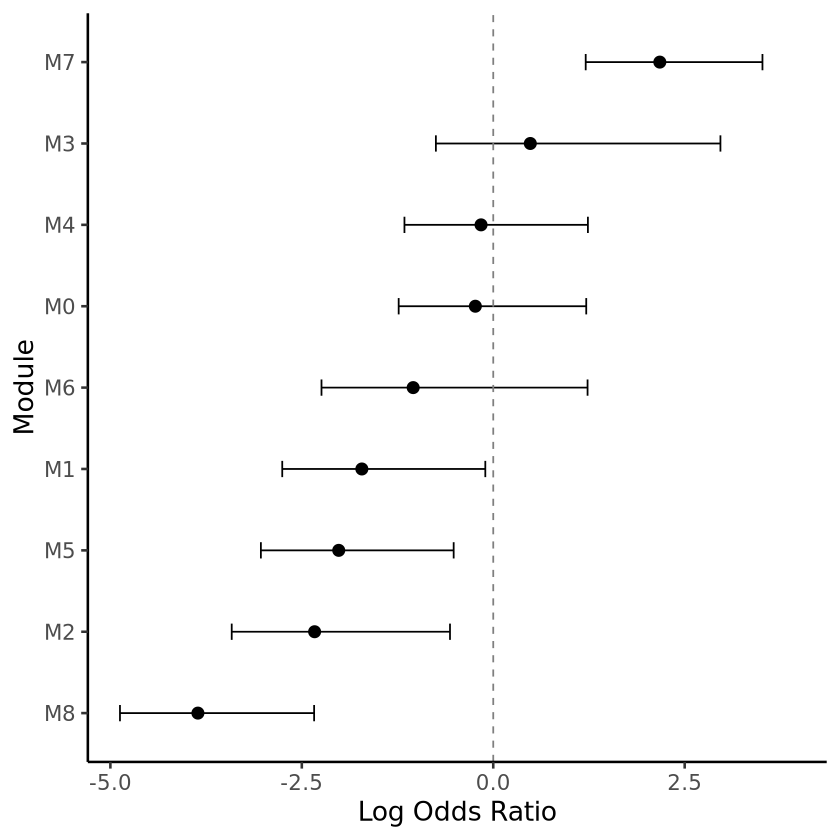

In [23]:
out.df.fdr$fold_enrich <- as.numeric(out.df.fdr$fold_enrich)
out.df.fdr$logOR <- as.numeric(out.df.fdr$logOR)
out.df.fdr$conf_lower <- as.numeric(out.df.fdr$conf_lower)
out.df.fdr$conf_upper <- as.numeric(out.df.fdr$conf_upper)


ggplot(out.df.fdr, aes(x = logOR, y = reorder(module, fold_enrich))) +
  geom_point(size = 3) +
  geom_errorbarh(aes(xmin = conf_lower, xmax = conf_upper), height = 0.2) +
  theme_classic(base_size = 16) +
  labs(x = "Log Odds Ratio", y = "Module") +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50") +
  scale_x_continuous(expand = expansion(mult = c(0.05, 0.1)))

In [2]:
out.df.fdr <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/250428_cre.modules.tsv', header=T, sep='\t')
out.df.fdr

module,pval,fold_enrich,logOR,conf_lower,conf_upper,qval,enriched.celltype
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
M7,0.000,4.16018773,2.1753011,1.2073658,3.5158098,0.000,Hepatocytes
M3,0.216,1.56321207,0.4839532,-0.7492147,2.9668353,0.972,Cholangiocytes
M4,0.552,0.87141595,-0.1592970,-1.1596688,1.2360971,1.000,Myeloid
M0,0.620,0.81338929,-0.2338241,-1.2351061,1.2143438,1.000,T_NK
M6,0.773,0.36801624,-1.0457128,-2.2430238,1.2316501,1.000,B
M1,0.964,0.19703578,-1.7160692,-2.7556172,-0.1037159,1.000,Endothelial
M5,0.990,0.14879791,-2.0178945,-3.0345592,-0.5169196,1.000,Schwann
M2,0.991,0.10619469,-2.3328834,-3.4154508,-0.5648617,1.000,Mast
M8,1.000,0.02391667,-3.8569630,-4.8748765,-2.3393083,1.000,HSC


In [4]:
out.df.fdr <- mutate(out.df.fdr, enriched.celltype=ifelse(enriched.celltype=='T_NK','Shared',enriched.celltype))
out.df.fdr

module,pval,fold_enrich,logOR,conf_lower,conf_upper,qval,enriched.celltype
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
M7,0.000,4.16018773,2.1753011,1.2073658,3.5158098,0.000,Hepatocytes
M3,0.216,1.56321207,0.4839532,-0.7492147,2.9668353,0.972,Cholangiocytes
M4,0.552,0.87141595,-0.1592970,-1.1596688,1.2360971,1.000,Myeloid
M0,0.620,0.81338929,-0.2338241,-1.2351061,1.2143438,1.000,Shared
M6,0.773,0.36801624,-1.0457128,-2.2430238,1.2316501,1.000,B
M1,0.964,0.19703578,-1.7160692,-2.7556172,-0.1037159,1.000,Endothelial
M5,0.990,0.14879791,-2.0178945,-3.0345592,-0.5169196,1.000,Schwann
M2,0.991,0.10619469,-2.3328834,-3.4154508,-0.5648617,1.000,Mast
M8,1.000,0.02391667,-3.8569630,-4.8748765,-2.3393083,1.000,HSC


In [5]:
mod.colors <- c(M0_Shared='#e1C2aa',
                M1_Endothelial='#c8e0ba',
                M2_Mast='#95bfac',
                M3_Cholangiocytes='#bbece9',
                M4_Myeloid='#a3ccd0',
                M5_Schwann='#8cc9ea',
                M6_B='#b9c0d9',
                M7_Hepatocytes='#cab8e5',
                M8_HSC='#e7bfd0')

module,pval,fold_enrich,logOR,conf_lower,conf_upper,qval,enriched.celltype,label,mod_ct
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
M7,0.000,4.16018773,2.1753011,1.2073658,3.5158098,0.000,Hepatocytes,***,M7_Hepatocytes
M3,0.216,1.56321207,0.4839532,-0.7492147,2.9668353,0.972,Cholangiocytes,,M3_Cholangiocytes
M4,0.552,0.87141595,-0.1592970,-1.1596688,1.2360971,1.000,Myeloid,,M4_Myeloid
M0,0.620,0.81338929,-0.2338241,-1.2351061,1.2143438,1.000,Shared,,M0_Shared
M6,0.773,0.36801624,-1.0457128,-2.2430238,1.2316501,1.000,B,,M6_B
M1,0.964,0.19703578,-1.7160692,-2.7556172,-0.1037159,1.000,Endothelial,,M1_Endothelial
M5,0.990,0.14879791,-2.0178945,-3.0345592,-0.5169196,1.000,Schwann,,M5_Schwann
M2,0.991,0.10619469,-2.3328834,-3.4154508,-0.5648617,1.000,Mast,,M2_Mast
M8,1.000,0.02391667,-3.8569630,-4.8748765,-2.3393083,1.000,HSC,,M8_HSC


pdf 
  2

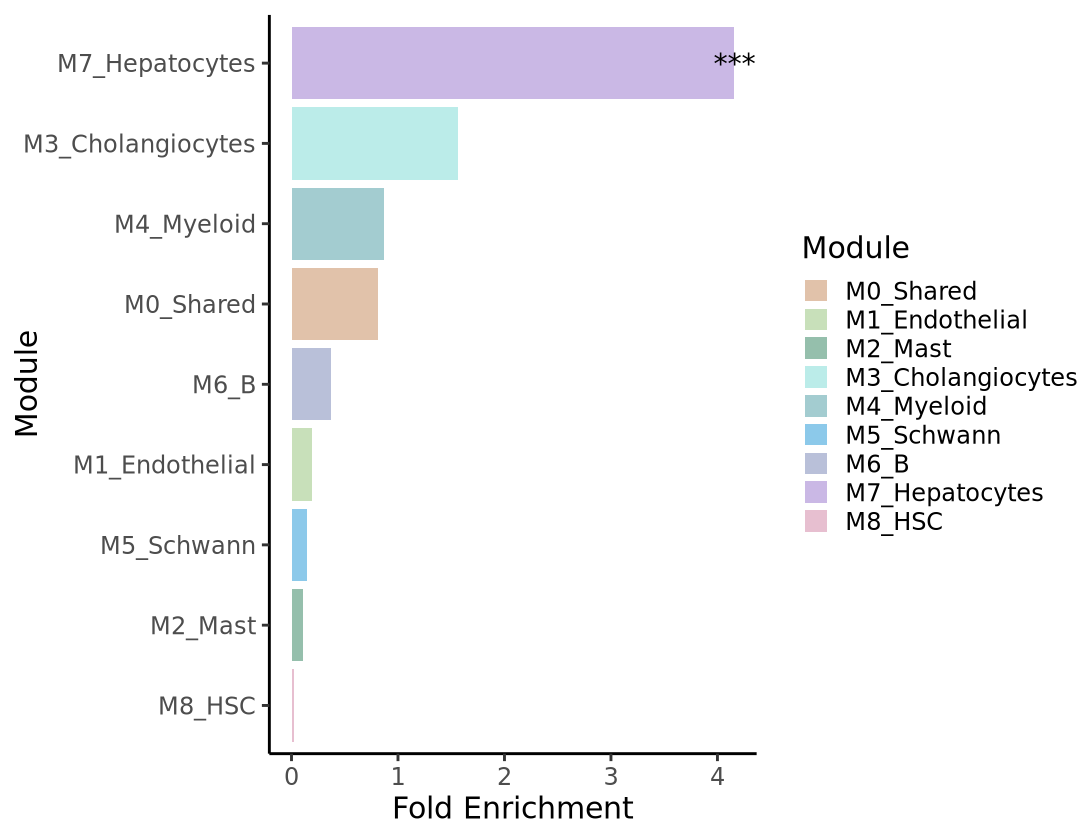

In [12]:
library(ggplot2)
library(dplyr)

options(repr.plot.width=9)

out.df.fdr <- mutate(out.df.fdr, label=ifelse(qval<0.001, '***',
                                       ifelse(qval < 0.01, '**',
                                       ifelse(qval < 0.1, '*',''))),
                    mod_ct=paste0(module, '_', enriched.celltype))

out.df.fdr

ggplot(out.df.fdr, aes(x = fold_enrich, y = reorder(mod_ct, fold_enrich), fill=mod_ct, label=label)) +
    geom_col(size = 3) +
    theme_classic(base_size = 18) +
    labs(x = "Fold Enrichment", y = "Module", fill = 'Module') +
    scale_fill_manual(values=mod.colors) +
    geom_text(size=6)
    

pdf('/nfs/lab/welison/Liver/Plots/250428_WE_Module_Enrichment_v2.pdf', width=9)
ggplot(out.df.fdr, aes(x = fold_enrich, y = reorder(mod_ct, fold_enrich), fill=mod_ct, label=label)) +
    geom_col(size = 3) +
    theme_classic(base_size = 18) +
    labs(x = "Fold Enrichment", y = "Module", fill = 'Module') +
    scale_fill_manual(values=mod.colors) +
    geom_text(size=6)
dev.off()

# Read HOMER

In [ ]:
homer.state <- data.frame()
for (CELL in c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Mast','Myeloid','NK','Schwann','T')) {
    for (state in names(states)) { 
        file <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/outs/cre.states.',state,'.',CELL,'/knownResults.txt')
        if (!file.exists(file)) {
            next
        }
        homer.state <- vroom::vroom(file) %>%
            mutate(celltype=CELL,state=state) %>%
            select(Motif.Name=`Motif Name`, p.value=`P-value`, log.p.value=`Log P-value`, 
                   q.value=`q-value (Benjamini)`, num.target.seqs.with.motif=contains("# of Target Sequences with Motif(of "),
                  perc.target.seqs.with.motif=`% of Target Sequences with Motif`,
                  num.background.seqs.with.motif=contains("# of Background Sequences with Motif(of "),
                  perc.background.seqs.with.motif=`% of Background Sequences with Motif`, celltype, state) %>%
            mutate(perc.target.seqs.with.motif=as.numeric(str_remove(perc.target.seqs.with.motif, '%')),
                  perc.background.seqs.with.motif=as.numeric(str_remove(perc.background.seqs.with.motif, '%'))) %>%
            mutate(FC=(perc.target.seqs.with.motif/perc.background.seqs.with.motif),
                  L2FC=log2(abs(FC))) %>%
            rbind(homer.state)
    }
}

print(692 * 10 * 5)
dim(homer.state)
head(homer.state)

write.table(homer.state, '/nfs/lab/tscc/welison/FNIH.Liver/12_HOMER/250408_cRE_states_JASPAR2022.tsv', sep='\t', col.names=T, row.names=F, quote=F)

In [ ]:
filter(homer.state, celltype=='Hepatocytes' & q.value < 0.05)